### Pandas Task

<img src="./images/happiness_report_2023.png" width="450" style="margin-left: 0px;">

In [1]:
import pandas as pd

# ./datasets/happiness_report_2023.csv 불러오기
happiness_df = pd.read_csv('./datasets/happiness_report_2023.csv')
happiness_df.info()
happiness_df.describe().T

# 전체 데이터 중 상위 4개, 하위 4개 불러오기
display(happiness_df.head(4))
display(happiness_df.tail(4))

# shpae 확인하기
print(happiness_df.shape)

# country, region, happiness_score, gdp_per_capita 컬럼 데이터 추출한 뒤 출력하기
happiness_df2 = happiness_df[['country', 'region', 'happiness_score', 'gdp_per_capita']]
display(happiness_df2)

<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       137 non-null    str    
 1   region                        137 non-null    str    
 2   happiness_score               137 non-null    float64
 3   gdp_per_capita                137 non-null    float64
 4   social_support                137 non-null    float64
 5   healthy_life_expectancy       136 non-null    float64
 6   freedom_to_make_life_choices  137 non-null    float64
 7   generosity                    137 non-null    float64
 8   perceptions_of_corruption     137 non-null    float64
dtypes: float64(7), str(2)
memory usage: 9.8 KB


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051
135,Lebanon,Middle East and North Africa,2.392,1.417,0.476,0.398,0.123,0.061,0.027
136,Afghanistan,South Asia,1.859,0.645,0.000,0.087,0.000,0.093,0.059


(137, 9)


,country,region,happiness_score,gdp_per_capita
0,Finland,Western Europe,7.804,1.888
1,Denmark,Western Europe,7.586,1.949
2,Iceland,Western Europe,7.530,1.926
3,Israel,Middle East and North Africa,7.473,1.833
4,Netherlands,Western Europe,7.403,1.942
...,...,...,...,...
132,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670
135,Lebanon,Middle East and North Africa,2.392,1.417


,country,region,happiness_score,gdp_per_capita
0,Finland,Western Europe,7.804,1.888
1,Denmark,Western Europe,7.586,1.949
2,Iceland,Western Europe,7.530,1.926


,count,mean,std,min,25%,50%,75%,max
happiness_score,137.0,5.539796,1.139929,1.859,4.724,5.684,6.334,7.804
gdp_per_capita,137.0,1.406985,0.432963,0.000,1.099,1.449,1.798,2.200


,happiness_score
0,5.277
1,6.125
2,6.144


happiness_score
6.144    2
6.125    2
5.277    2
7.804    1
Name: count, dtype: int64


,gdp_per_capita
0,0.914
1,1.417
2,1.714
3,1.798


gdp_per_capita
1.798    2
1.714    2
1.417    2
0.914    2
1.888    1
Name: count, dtype: int64


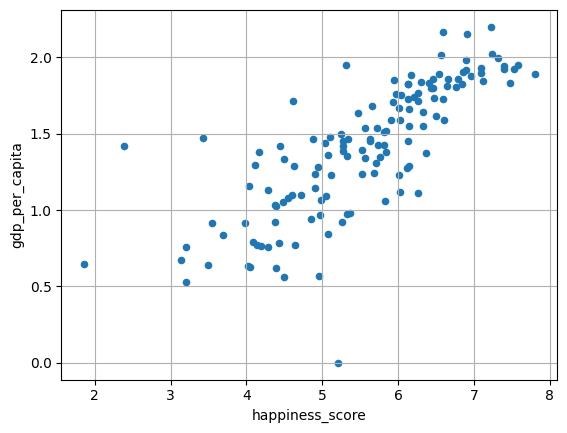

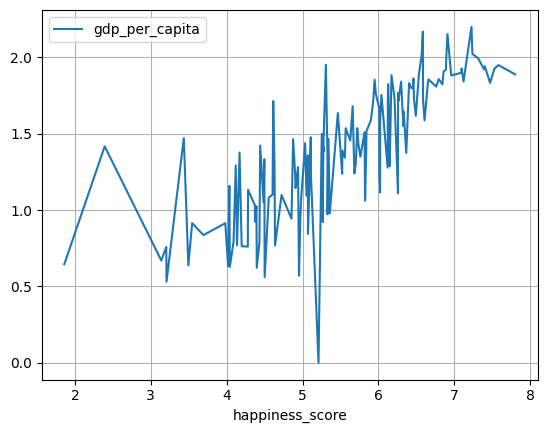

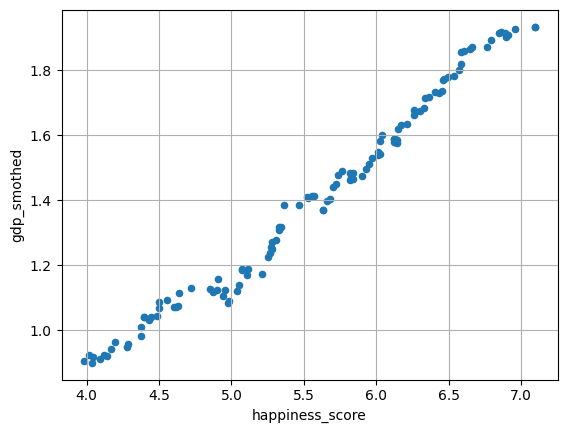

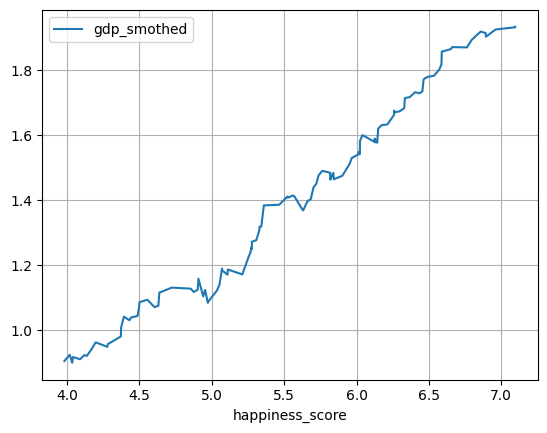

In [2]:
import matplotlib.pyplot as plt

# 아래 4가지 컬럼으로 축소한 뒤 상위 3개의 데이터를 출력한다.
# country, region, happiness_score, gdp_per_capita
happiness_df_gdp = happiness_df[['country', 'region', 'happiness_score', 'gdp_per_capita']]
display(happiness_df_gdp.head(3))

# 평균, 표준편차, 최소값, 4분위 분포도, 최대값을 출력한다.
display(happiness_df_gdp.describe().T)

# 행복지수 최빈값과 1인당 GDP 최빈값을 출력한다.
display(happiness_df_gdp[['happiness_score']].mode())
print(happiness_df_gdp.happiness_score.value_counts().head(4))
display(happiness_df_gdp[['gdp_per_capita']].mode())
print(happiness_df_gdp.gdp_per_capita.value_counts().head(5))

# 행복지수와 1인당 GDP를 활용하여 분포도(scatter) 그래프와 선(line) 그래프를 출력한다.
happiness_df_gdp.plot(x="happiness_score", y="gdp_per_capita", grid=True, kind="scatter")
happiness_df_gdp.plot(x="happiness_score", y="gdp_per_capita", grid=True, kind="line")

plt.show()

# window=20으로 가정한다면,
# center=False(기본값): 현재 데이터 + 직전 19개 데이터, 과거 중심 데이터
# center=True: 현재 데이터 앞 뒤로 약 10개씩
happiness_df_gdp['gdp_smothed'] = happiness_df_gdp.gdp_per_capita.rolling(window=20, center=True).mean()
happiness_df_gdp.plot(x="happiness_score", y="gdp_smothed", grid=True, kind="scatter")
happiness_df_gdp.plot(x="happiness_score", y="gdp_smothed", grid=True, kind="line")

plt.show()

In [3]:
# region이 Sub-Saharan Africa인 행 인덱스 출력
happiness_df[happiness_df.region == 'Sub-Saharan Africa'].index

Index([ 58,  84,  85,  90,  92,  93,  94,  95,  96, 101, 102, 103, 104, 106,
       108, 110, 112, 113, 115, 118, 119, 121, 123, 124, 126, 127, 128, 129,
       130, 131, 132, 133, 134],
      dtype='int64')

In [4]:
happiness_df.shape

(137, 9)

In [5]:
# region이 Sub-Saharan Africa인 행 삭제
indices = happiness_df[happiness_df.region == 'Sub-Saharan Africa'].index
happiness_df = happiness_df.drop(index=indices, axis=0)
happiness_df.shape

(104, 9)

In [6]:
import numpy as np
# gdp_per_capita를 정수(int16)로 변환 후 새로운 컬럼인 gdp_per_capita_int에 저장
happiness_df = pd.read_csv('./datasets/happiness_report_2023.csv')
happiness_df['gdp_per_capita_int'] = happiness_df.gdp_per_capita.astype(np.int16)
happiness_df

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,gdp_per_capita_int
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535,1
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525,1
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187,1
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158,1
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394,1
...,...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068,0
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117,0
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051,0
135,Lebanon,Middle East and North Africa,2.392,1.417,0.476,0.398,0.123,0.061,0.027,1


In [7]:
#gdp_per_capita_int 컬럼명을 gdp_int로 변경
happiness_df = happiness_df.rename(columns={'gdp_per_capita_int': 'gdp_int'})
happiness_df

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,gdp_int
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535,1
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525,1
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187,1
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158,1
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394,1
...,...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068,0
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117,0
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051,0
135,Lebanon,Middle East and North Africa,2.392,1.417,0.476,0.398,0.123,0.061,0.027,1


In [8]:
# gdp_per_capita가 2이상인 country 조회 후 index 재정렬
happiness_df[happiness_df.gdp_per_capita >= 2].reset_index(drop=True)

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,gdp_int
0,Switzerland,Western Europe,7.240,2.022,1.463,0.582,0.678,0.151,0.475,2
1,Luxembourg,Western Europe,7.228,2.200,1.357,0.549,0.710,0.149,0.418,2
2,Ireland,Western Europe,6.911,2.152,1.425,0.539,0.656,0.186,0.409,2
3,Singapore,Southeast Asia,6.587,2.168,1.354,0.607,0.660,0.170,0.561,2
4,United Arab Emirates,Middle East and North Africa,6.571,2.015,1.223,0.401,0.745,0.188,0.247,2


In [9]:
# country, region, happiness_score, healthy_life_expectancy를 추출한 뒤 
# healthy_life_expectancy를 기준으로 내림차순 후 출력
happiness_df_gdp = happiness_df[['country', 'region', 'happiness_score', 'healthy_life_expectancy']]
happiness_df_gdp.sort_values('healthy_life_expectancy', inplace=True, ascending=False)
happiness_df_gdp

,country,region,happiness_score,healthy_life_expectancy
81,Hong Kong S.A.R. of China,East Asia,5.308,0.702
46,Japan,East Asia,6.129,0.622
24,Singapore,Southeast Asia,6.587,0.607
56,South Korea,East Asia,5.951,0.603
7,Switzerland,Western Europe,7.240,0.582
...,...,...,...,...
90,Guinea,Sub-Saharan Africa,5.072,0.072
133,Zimbabwe,Sub-Saharan Africa,3.204,0.069
113,Chad,Sub-Saharan Africa,4.397,0.043
96,Mozambique,Sub-Saharan Africa,4.954,0.000


#### 데이터 불러오기

In [10]:
import numpy as np
import pandas as pd

happiness_df = pd.read_csv('./datasets/happiness_report_2023.csv')
happiness_df.info()
happiness_df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       137 non-null    str    
 1   region                        137 non-null    str    
 2   happiness_score               137 non-null    float64
 3   gdp_per_capita                137 non-null    float64
 4   social_support                137 non-null    float64
 5   healthy_life_expectancy       136 non-null    float64
 6   freedom_to_make_life_choices  137 non-null    float64
 7   generosity                    137 non-null    float64
 8   perceptions_of_corruption     137 non-null    float64
dtypes: float64(7), str(2)
memory usage: 9.8 KB


,count,mean,std,min,25%,50%,75%,max
happiness_score,137.0,5.539796,1.139929,1.859,4.7240,5.6840,6.3340,7.804
gdp_per_capita,137.0,1.406985,0.432963,0.000,1.0990,1.4490,1.7980,2.200
social_support,137.0,1.156212,0.326322,0.000,0.9620,1.2270,1.4010,1.620
healthy_life_expectancy,136.0,0.366176,0.156691,0.000,0.2485,0.3895,0.4875,0.702
freedom_to_make_life_choices,137.0,0.540000,0.149501,0.000,0.4550,0.5570,0.6560,0.772
generosity,137.0,0.148474,0.076053,0.000,0.0970,0.1370,0.1990,0.422
perceptions_of_corruption,137.0,0.145898,0.126723,0.000,0.0600,0.1110,0.1870,0.561


#### 결측치

In [11]:
happiness_df.isna().sum()

country                         0
region                          0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         1
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64

In [12]:
happiness_df.healthy_life_expectancy = \
    happiness_df.healthy_life_expectancy \
        .fillna(happiness_df.healthy_life_expectancy.median())

In [13]:
happiness_df.isna().sum()

country                         0
region                          0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64

#### 중복행

In [15]:
happiness_df.duplicated().sum()

np.int64(0)

In [16]:
# subset: 대상 컬럼, 기본값은 전체 컬럼
# keep: 중복 시, 몇 번째를 삭제할 것인지, 기본값은 first
# ignore_index: 중복 제거 후 인덱스 reset

# happiness_df.drop_duplicates(subset=[], keep='first', ignore_index=True, inplace=True)
happiness_df.drop_duplicates(ignore_index=True, inplace=True)

#### 이상치

In [48]:
from scipy.stats import iqr
# 이상치 제거
happiness_score_Q1 = np.percentile(happiness_df.happiness_score, 25)
happiness_score_Q3 = np.percentile(happiness_df.happiness_score, 75)

iqr_value = iqr(happiness_df.happiness_score)

lower_bound = happiness_score_Q1 - 1.5 * iqr_value
upper_bound = happiness_score_Q1 + 1.5 * iqr_value
print(f'정상치 범위: {lower_bound} ~ {upper_bound}')

정상치 범위: 2.309000000000001 ~ 7.138999999999999


In [49]:
condition1 = happiness_df.happiness_score >= lower_bound
condition2 = happiness_df.happiness_score <= upper_bound
condition = condition1 & condition2

happiness_df = happiness_df[condition]
happiness_df

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394
5,Sweden,Western Europe,7.395,1.921,1.510,0.562,0.754,0.225,0.520
6,Norway,Western Europe,7.315,1.994,1.521,0.544,0.752,0.212,0.463
7,Switzerland,Western Europe,7.240,2.022,1.463,0.582,0.678,0.151,0.475
8,Luxembourg,Western Europe,7.228,2.200,1.357,0.549,0.710,0.149,0.418
136,Afghanistan,South Asia,1.859,0.645,0.000,0.087,0.000,0.093,0.059


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
9,New Zealand,North America and ANZ,7.123,1.842,1.544,0.513,0.672,0.230,0.471
10,Austria,Western Europe,7.097,1.927,1.382,0.535,0.630,0.191,0.310
11,Australia,North America and ANZ,7.095,1.899,1.497,0.532,0.677,0.242,0.310
12,Canada,North America and ANZ,6.961,1.881,1.484,0.541,0.656,0.218,0.364
13,Ireland,Western Europe,6.911,2.152,1.425,0.539,0.656,0.186,0.409
...,...,...,...,...,...,...,...,...,...
131,Botswana,Sub-Saharan Africa,3.435,1.471,1.041,0.087,0.480,0.021,0.071
132,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051


In [50]:
happiness_df.reset_index(drop=True, inplace=True)
happiness_df

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,New Zealand,North America and ANZ,7.123,1.842,1.544,0.513,0.672,0.230,0.471
1,Austria,Western Europe,7.097,1.927,1.382,0.535,0.630,0.191,0.310
2,Australia,North America and ANZ,7.095,1.899,1.497,0.532,0.677,0.242,0.310
3,Canada,North America and ANZ,6.961,1.881,1.484,0.541,0.656,0.218,0.364
4,Ireland,Western Europe,6.911,2.152,1.425,0.539,0.656,0.186,0.409
...,...,...,...,...,...,...,...,...,...
122,Botswana,Sub-Saharan Africa,3.435,1.471,1.041,0.087,0.480,0.021,0.071
123,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068
124,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
125,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051


In [51]:
happiness_df.describe().T

,count,mean,std,min,25%,50%,75%,max
happiness_score,127.0,5.434008,1.011587,2.392,4.6345,5.569,6.1930,7.123
gdp_per_capita,127.0,1.373520,0.416839,0.000,1.0875,1.422,1.7265,2.168
social_support,127.0,1.140063,0.307627,0.242,0.9520,1.213,1.3825,1.544
healthy_life_expectancy,127.0,0.355217,0.151726,0.000,0.2440,0.387,0.4735,0.702
freedom_to_make_life_choices,127.0,0.532291,0.139527,0.117,0.4500,0.551,0.6310,0.768
generosity,127.0,0.146079,0.077021,0.000,0.0940,0.134,0.1920,0.422
perceptions_of_corruption,127.0,0.127984,0.103675,0.000,0.0590,0.102,0.1640,0.561


In [52]:
from scipy.stats import iqr
# 이상치 제거
gdp_per_capita_Q1 = np.percentile(happiness_df.gdp_per_capita, 25)
gdp_per_capita_Q3 = np.percentile(happiness_df.gdp_per_capita, 75)

iqr_value = iqr(happiness_df.gdp_per_capita)

lower_bound = gdp_per_capita_Q1 - 1.5 * iqr_value
upper_bound = gdp_per_capita_Q3 + 1.5 * iqr_value
print(f'정상치 범위: {lower_bound} ~ {upper_bound}')

정상치 범위: 0.12899999999999956 ~ 2.6850000000000005


In [53]:
condition1 = happiness_df.gdp_per_capita >= lower_bound
condition2 = happiness_df.gdp_per_capita <= upper_bound
condition = condition1 & condition2

happiness_df = happiness_df[condition]
happiness_df

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,New Zealand,North America and ANZ,7.123,1.842,1.544,0.513,0.672,0.230,0.471
1,Austria,Western Europe,7.097,1.927,1.382,0.535,0.630,0.191,0.310
2,Australia,North America and ANZ,7.095,1.899,1.497,0.532,0.677,0.242,0.310
3,Canada,North America and ANZ,6.961,1.881,1.484,0.541,0.656,0.218,0.364
4,Ireland,Western Europe,6.911,2.152,1.425,0.539,0.656,0.186,0.409
...,...,...,...,...,...,...,...,...,...
122,Botswana,Sub-Saharan Africa,3.435,1.471,1.041,0.087,0.480,0.021,0.071
123,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068
124,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
125,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051


In [54]:
happiness_df.reset_index(drop=True, inplace=True)
happiness_df

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,New Zealand,North America and ANZ,7.123,1.842,1.544,0.513,0.672,0.230,0.471
1,Austria,Western Europe,7.097,1.927,1.382,0.535,0.630,0.191,0.310
2,Australia,North America and ANZ,7.095,1.899,1.497,0.532,0.677,0.242,0.310
3,Canada,North America and ANZ,6.961,1.881,1.484,0.541,0.656,0.218,0.364
4,Ireland,Western Europe,6.911,2.152,1.425,0.539,0.656,0.186,0.409
...,...,...,...,...,...,...,...,...,...
121,Botswana,Sub-Saharan Africa,3.435,1.471,1.041,0.087,0.480,0.021,0.071
122,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068
123,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
124,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051


In [55]:
happiness_df.describe().T

,count,mean,std,min,25%,50%,75%,max
happiness_score,126.0,5.435778,1.015428,2.392,4.63275,5.5995,6.20300,7.123
gdp_per_capita,126.0,1.384421,0.399915,0.531,1.09525,1.4235,1.72675,2.168
social_support,126.0,1.139135,0.308676,0.242,0.95150,1.2125,1.38275,1.544
healthy_life_expectancy,126.0,0.355329,0.152326,0.000,0.24400,0.3880,0.47425,0.702
freedom_to_make_life_choices,126.0,0.533587,0.139314,0.117,0.45200,0.5510,0.63100,0.768
generosity,126.0,0.145611,0.077148,0.000,0.09350,0.1340,0.19050,0.422
perceptions_of_corruption,126.0,0.128333,0.104014,0.000,0.05900,0.1020,0.16450,0.561


#### 분포도 확인

<Axes: >

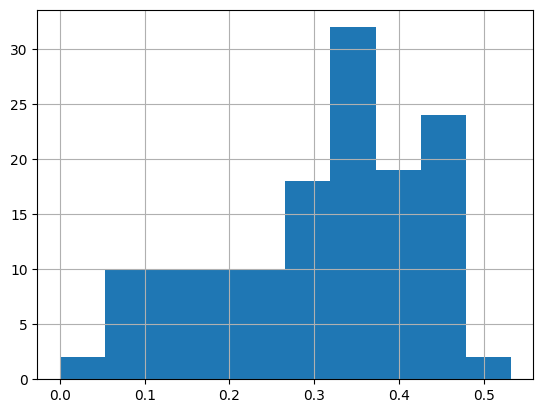

In [26]:
import numpy as np

# happiness_df.hist()
# np.log1p(happiness_df.gdp_per_capita).hist()
# np.log1p(happiness_df.healthy_life_expectancy).hist()

#### 시각화

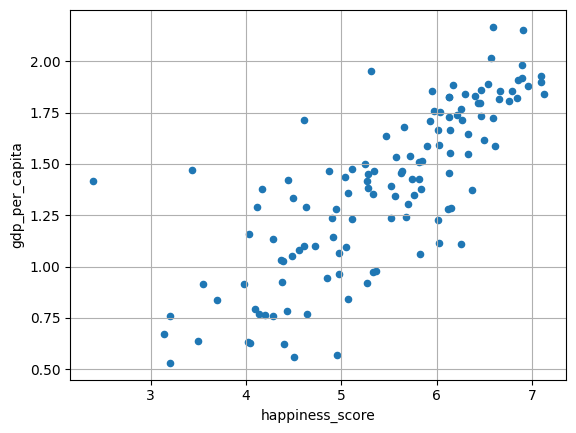

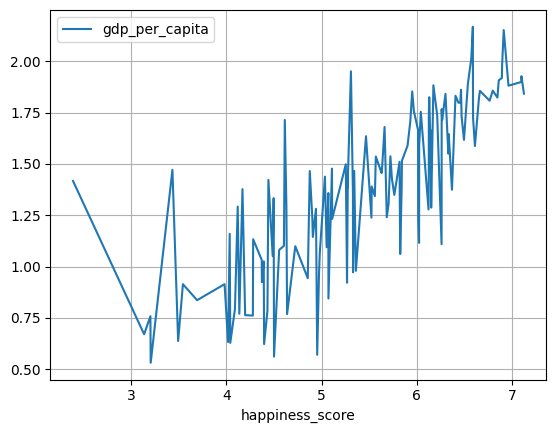

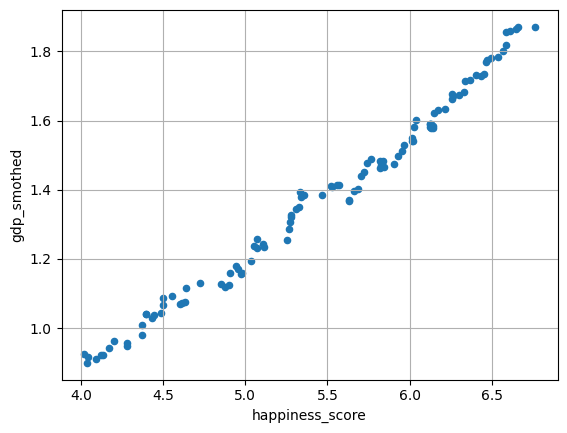

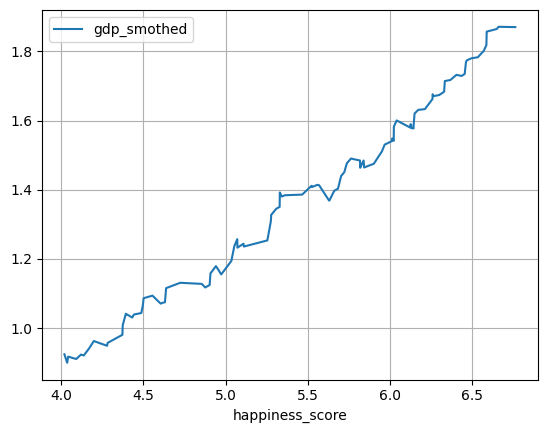

In [58]:
# 행복지수와 1인당 GDP를 활용하여 분포도(scatter) 그래프와 선(line) 그래프를 출력한다.
happiness_df.plot(x="happiness_score", y="gdp_per_capita", grid=True, kind="scatter")
happiness_df.plot(x="happiness_score", y="gdp_per_capita", grid=True, kind="line")

plt.show()

# window=20으로 가정한다면,
# center=False(기본값): 현재 데이터 + 직전 19개 데이터, 과거 중심 데이터
# center=True: 현재 데이터 앞 뒤로 약 10개씩
happiness_df['gdp_smothed'] = happiness_df.gdp_per_capita.rolling(window=20, center=True).mean()
happiness_df.plot(x="happiness_score", y="gdp_smothed", grid=True, kind="scatter")
happiness_df.plot(x="happiness_score", y="gdp_smothed", grid=True, kind="line")

plt.show()